In [74]:
## 4.5. Run RB Protocol with Truncations
def run_rb_protocol_with_truncations(clifford_circuits, sequence_length, num_sequences, shots, backend, noise_model, target_gate_circuit=None, seed_base=54321):
    """
    Implements RB protocol with truncations as described in the referenced paper.
    For each random sequence, generates all truncations, appends the correct inverse, and collects survival probabilities.
    Returns: survival_probs[m][k] for each truncation length m and sequence k.
    """
    from qiskit.quantum_info import Clifford
    sim = AerSimulator()
    survival_probs = np.zeros((sequence_length, num_sequences))
    for k in range(num_sequences):
        seed = seed_base + sequence_length * 1000 + k
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(clifford_circuits), size=sequence_length, replace=True)
        # Build up the sequence one truncation at a time
        for m in range(1, sequence_length + 1):
            qc = QuantumCircuit(2, 2)
            clifford_product = Clifford(np.eye(4))
            for idx in indices[:m]:
                qc.compose(clifford_circuits[idx], inplace=True)
                clifford_product = clifford_product.compose(Clifford(clifford_circuits[idx]))
                if target_gate_circuit is not None:
                    qc.compose(target_gate_circuit, inplace=True)
                    clifford_product = clifford_product.compose(Clifford(target_gate_circuit))
            # Compute inverse for this truncation
            inv_cliff = clifford_product.adjoint()
            qc.compose(inv_cliff.to_circuit(), inplace=True)
            qc.measure([0, 1], [0, 1])
            transpiled = transpile(qc, backend=backend)
            job = sim.run(transpiled, shots=shots, noise_model=noise_model)
            result = job.result()
            counts = result.get_counts()
            prob = counts.get('00', 0) / shots  # For 2 qubits
            survival_probs[m-1, k] = prob
    # Average over sequences for each truncation length
    avg_survival_probs = np.mean(survival_probs, axis=1)
    return avg_survival_probs
{
    "cells": [
        {
            "cell_type": "markdown",
            "id": "#VSC-739103c0",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "# Randomized Benchmarking with ibm_fez Noise Model",
                "",
                "This notebook implements:",
                "1. Noise model extraction from IBM Quantum hardware (ibm_fez)",
                "2. Standard Randomized Benchmarking (RB) to extract depolarizing parameter p",
                "3. Interleaved Randomized Benchmarking (IRB) to characterize specific gates",
                "4. Simulation and data analysis"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-41d41bbe",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## Setup and Imports"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-9ba8a8b3",
            "metadata": {
                "language": "python"
            },
            "source": [
                "%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib pandas"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-0067b57b",
            "metadata": {
                "language": "python"
            },
            "source": [
                "import numpy as np",
                "import matplotlib.pyplot as plt",
                "from qiskit import QuantumCircuit, transpile",
                "from qiskit.quantum_info import Operator",
                "from qiskit_aer import AerSimulator",
                "from qiskit_ibm_runtime import QiskitRuntimeService",
                "import scipy",
                "",
                "# Import NoiseModel with fallback",
                "try:",
                "    from qiskit_aer.noise import NoiseModel",
                "except Exception:",
                "    try:",
                "        from qiskit.providers.aer.noise import NoiseModel",
                "    except Exception:",
                "        raise ImportError(\"NoiseModel import failed — install qiskit-aer\")",
                "",
                "print(\"Imports successful!\")"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-34a04180",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 1. Create Noise Model from ibm_fez Hardware"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-8bcaebbe",
            "metadata": {
                "language": "python"
            },
            "source": [
                "IBM_QUANTUM_TOKEN = \"r4IqbTTUxpez5jP4UIcfKOo-f8xki_93SKdFYCNUASB7\"",
                "",
                "# Connect to IBM Quantum service",
                "service = QiskitRuntimeService(channel=\"ibm_quantum_platform\", token=IBM_QUANTUM_TOKEN)",
                "backend = service.backend(\"ibm_fez\")",
                "",
                "# Extract full noise model from real hardware (cannot restrict to qubits directly in Qiskit 0.45+ API)",
                "noise_model = NoiseModel.from_backend(backend)",
                "# Note: To restrict to qubits 1 and 2, you must filter errors manually or ensure your circuits only use those qubits.",
                "# The noise model will still contain errors for all qubits, but only qubits 1 and 2 will be used in your circuits.",
                "",
                "print(f\"✓ Connected to {backend.name}\")",
                "print(f\"✓ Noise model extracted (full backend, {len(noise_model.to_dict().get('errors', {}))} error definitions)\")",
                "print(f\"  Basis gates: {noise_model.basis_gates}\")"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-c740fee0",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 2. Generate Single-Qubit Clifford Group"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-5d3e5447",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# 2-qubit Clifford group generation using Qiskit (approximate, for demonstration)",
                "from qiskit.quantum_info import random_clifford",
                "def generate_two_qubit_cliffords(n=2, num=100):",
                "    \"\"\"Generate a list of random 2-qubit Clifford circuits (not exhaustive, for demo).\"\"\"",
                "    circuits = []",
                "    for _ in range(num):",
                "        cliff = random_clifford(n)",
                "        qc = cliff.to_circuit()",
                "        # Only add if not equivalent to any already in list",
                "        if not any(np.allclose(Operator(qc).data, Operator(existing).data, atol=1e-6) for existing in circuits):",
                "            circuits.append(qc)",
                "        if len(circuits) >= num:",
                "            break",
                "    return circuits",
                "",
                "# Generate 2-qubit Cliffords (approximate, not exhaustive)",
                "cliffords_list = generate_two_qubit_cliffords(num=100)",
                "",
                "print(f\"✓ Generated {len(cliffords_list)} 2-qubit Clifford circuits (random sample)\")"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-c8a2d348",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 3. Create RB/IRB Sequence Function"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-32f85218",
            "metadata": {
                "language": "python"
            },
            "source": [
                "from qiskit.quantum_info import Clifford",
                "",
                "def create_rb_sequence(clifford_circuits, m, target_gate_circuit=None, seed=None):",
                "    \"\"\"",
                "    Create a 2-qubit RB or IRB sequence using Clifford objects for robust inverse calculation.",
                "    Args:",
                "        clifford_circuits: List of 2-qubit Clifford QuantumCircuits",
                "        m: Sequence length (number of random Cliffords)",
                "        target_gate_circuit: Gate to interleave (None for standard RB)",
                "        seed: Random seed for reproducibility",
                "    Returns:",
                "        QuantumCircuit with measurement",
                "    \"\"\"",
                "    rng = np.random.default_rng(seed)",
                "    indices = rng.choice(len(clifford_circuits), size=m, replace=True)",
                "    qc = QuantumCircuit(2, 2)",
                "    clifford_product = Clifford(np.eye(4))  # Start with identity",
                "",
                "    for idx in indices:",
                "        qc.compose(clifford_circuits[idx], inplace=True)",
                "        clifford_product = clifford_product.compose(Clifford(clifford_circuits[idx]))",
                "        if target_gate_circuit is not None:",
                "            qc.compose(target_gate_circuit, inplace=True)",
                "            clifford_product = clifford_product.compose(Clifford(target_gate_circuit))",
                "",
                "    # Compute inverse Clifford using Gottesman-Knill theorem",
                "    inv_cliff = clifford_product.adjoint()",
                "    qc.compose(inv_cliff.to_circuit(), inplace=True)",
                "    qc.measure([0, 1], [0, 1])",
                "    return qc",
                "",
                "print(\"✓ 2-qubit RB/IRB sequence function defined (Gottesman-Knill inverse)\")"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-18c73a58",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Helper: extract gate sequence from a circuit",
                "",
                "def extract_gate_sequence(qc, include_measure=False):",
                "    \"\"\"Return a tuple of gate operation names in order.",
                "    Set include_measure=True to include 'measure' operations.\"\"\"",
                "    names = []",
                "    for instruction, qargs, cargs in qc.data:",
                "        name = instruction.name",
                "        if not include_measure and name == 'measure':",
                "            continue",
                "        names.append(name)",
                "    return tuple(names)",
                ""
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-098e45c8",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 4. Standard RB - Extract Depolarizing Parameter p"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-79657cad",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Standard RB: No target gate interleaving",
                "sequence_lengths = [2, 4, 6, 8, 12]",
                "num_sequences = 30",
                "shots = 1024",
                "seed_base = 54321",
                "",
                "sim = AerSimulator()",
                "survival_probs_rb = []",
                "",
                "print(\"Running Standard RB...\")",
                "for m in sequence_lengths:",
                "    probs = []",
                "    for k in range(num_sequences):",
                "        seed = seed_base + m * 1000 + k",
                "        rb_seq = create_rb_sequence(",
                "            clifford_circuits=cliffords_list,",
                "            m=m,",
                "            target_gate_circuit=None,  # No interleaving",
                "            seed=seed",
                "        )",
                "        rb_seq_transpiled = transpile(rb_seq, backend=backend)",
                "        job = sim.run(rb_seq_transpiled, shots=shots, noise_model=noise_model)",
                "        result = job.result()",
                "        counts = result.get_counts()",
                "        prob = counts.get('0', 0) / shots",
                "        probs.append(prob)",
                "    avg_prob = np.mean(probs)",
                "    survival_probs_rb.append(avg_prob)",
                "    print(f\"  m={m:2d}: F_seq = {avg_prob:.6f}\")",
                "",
                "print(\"✓ Standard RB complete\")"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-9088b068",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Fit Standard RB data to F_seq(m) = A * p^m + B",
                "m_vals = np.array(sequence_lengths)",
                "F_seq_rb = np.array(survival_probs_rb)",
                "",
                "def fit_func(m, A, p, B):",
                "    return A * p**m + B",
                "",
                "params_rb, _ = scipy.optimize.curve_fit(",
                "    fit_func, m_vals, F_seq_rb,",
                "    p0=[0.95, 0.98, 0.05],",
                "    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])",
                ")",
                "A_rb, p_rb, B_rb = params_rb",
                "# Use correct two-qubit formula: r = 3/4 * (1 - p)",
                "r_rb = 3/4 * (1 - p_rb)  # Average error per Clifford for 2 qubits",
                "",
                "print(f\"\\n=== Standard RB Results ===\")",
                "print(f\"Fit: F_seq(m) = {A_rb:.6f} × {p_rb:.8f}^m + {B_rb:.6f}\")",
                "print(f\"Depolarizing parameter p: {p_rb:.8f}\")",
                "print(f\"Average error per Clifford r: {r_rb:.8f} ({r_rb*100:.6f}%)\")",
                "print(f\"Gate fidelity: {(1-r_rb)*100:.6f}%\")"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-ae12e201",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# First-order RB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1",
                "",
                "def fit_func_first_order(m, A1, p1, C1, B1):",
                "    m = np.asarray(m, dtype=float)",
                "    return A1 * (p1 ** m) + C1 * (m - 1) * (p1 ** (m - 2)) + B1",
                "",
                "try:",
                "    params_rb_fo, _ = scipy.optimize.curve_fit(",
                "        fit_func_first_order,",
                "        m_vals,",
                "        F_seq_rb,",
                "        p0=[0.5, 0.99, 0.01, 0.5],",
                "        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])",
                "    )",
                "    A1_rb, p1_rb, C1_rb, B1_rb = params_rb_fo",
                "    r1_rb = (2 - 1) / 2 * (1 - p1_rb)",
                "    print(\"\\n=== Standard RB First-Order Fit ===\")",
                "    print(f\"Fit: F_seq^(1)(m) = {A1_rb:.6f} * {p1_rb:.8f}^m + {C1_rb:.6f} * (m-1) * {p1_rb:.8f}^(m-2) + {B1_rb:.6f}\")",
                "    print(f\"Depolarizing parameter p (first-order): {p1_rb:.8f}\")",
                "    print(f\"Average error per Clifford r (first-order): {r1_rb:.8f} ({r1_rb*100:.6f}%)\")",
                "except Exception as e:",
                "    print(f\"First-order RB fit failed: {e}\")"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-551fadbb",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 5. Interleaved RB - Characterize RX Gate"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-11643b07",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Define target gate (RZ(pi/2) gate) as a 2-qubit circuit (acts on qubit 0)",
                "target_RZ = QuantumCircuit(2)",
                "target_RZ.rz(np.pi/2, 0)",
                "",
                "# Interleaved RB: RZ(pi/2) gate after each Clifford",
                "survival_probs_irb = []",
                "",
                "print(\"Running Interleaved RB (RZ(pi/2) gate)...\")",
                "for m in sequence_lengths:",
                "    probs = []",
                "    for k in range(num_sequences):",
                "        seed = seed_base + m * 1000 + k + 99999",
                "        irb_seq = create_rb_sequence(",
                "            clifford_circuits=cliffords_list,",
                "            m=m,",
                "            target_gate_circuit=target_RZ,  # Interleave RZ(pi/2) gate",
                "            seed=seed",
                "        )",
                "        irb_seq_transpiled = transpile(irb_seq, backend=backend)",
                "        job = sim.run(irb_seq_transpiled, shots=shots, noise_model=noise_model)",
                "        result = job.result()",
                "        counts = result.get_counts()",
                "        prob = counts.get('0', 0) / shots",
                "        probs.append(prob)",
                "    avg_prob = np.mean(probs)",
                "    survival_probs_irb.append(avg_prob)",
                "    print(f\"  m={m:2d}: F_seq = {avg_prob:.6f}\")",
                "",
                "print(\"✓ Interleaved RB complete\")"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-93131667",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Fit Interleaved RB data (RZ)",
                "F_seq_irb = np.array(survival_probs_irb)",
                "",
                "params_irb, _ = scipy.optimize.curve_fit(",
                "    fit_func, m_vals, F_seq_irb,",
                "    p0=[0.95, 0.98, 0.05],",
                "    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])",
                ")",
                "A_irb, p_irb, B_irb = params_irb",
                "# Use correct two-qubit formula: r = 3/4 * (1 - p)",
                "r_irb = 3/4 * (1 - p_irb)",
                "",
                "# Calculate RZ gate error from comparison with standard RB",
                "# Formula: p_irb = p_rb * p_RZ (approximately)",
                "p_RZ = min(p_irb / p_rb if p_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]",
                "# Use correct two-qubit formula for gate error: r = 3/4 * (1 - p)",
                "r_RZ = 3/4 * (1 - p_RZ)",
                "",
                "print(f\"\\n=== Interleaved RB Results (RZ Gate) ===\")",
                "print(f\"Fit: F_seq(m) = {A_irb:.6f} × {p_irb:.8f}^m + {B_irb:.6f}\")",
                "print(f\"Depolarizing parameter p_irb: {p_irb:.8f}\")",
                "print(f\"Average error per (Clifford+RZ) r_irb: {r_irb:.8f} ({r_irb*100:.6f}%)\")",
                "print(f\"\\nRZ gate specific:\")",
                "print(f\"  p_RZ = p_irb / p_rb = {p_RZ:.8f}\")",
                "print(f\"  RZ gate error r_RZ: {r_RZ:.8f} ({r_RZ*100:.6f}%)\")",
                "print(f\"  RZ gate fidelity: {(1-r_RZ)*100:.6f}%\")"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-5ad63fc9",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# First-order IRB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1 (RZ)",
                "try:",
                "    params_irb_fo, _ = scipy.optimize.curve_fit(",
                "        fit_func_first_order,",
                "        m_vals,",
                "        F_seq_irb,",
                "        p0=[0.5, 0.99, 0.01, 0.5],",
                "        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])",
                "    )",
                "    A1_irb, p1_irb, C1_irb, B1_irb = params_irb_fo",
                "    r1_irb = (2 - 1) / 2 * (1 - p1_irb)",
                "    # Gate-specific first-order parameter via p_RZ1 ≈ p1_irb / p1_rb",
                "    p1_RZ = min(p1_irb / p1_rb if p1_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]",
                "    r1_RZ = (2 - 1) / 2 * (1 - p1_RZ)",
                "    print(\"\\n=== Interleaved RB First-Order Fit (RZ Gate) ===\")",
                "    print(f\"Fit: F_seq^(1)(m) = {A1_irb:.6f} * {p1_irb:.8f}^m + {C1_irb:.6f} * (m-1) * {p1_irb:.8f}^(m-2) + {B1_irb:.6f}\")",
                "    print(f\"Depolarizing parameter p_irb (first-order): {p1_irb:.8f}\")",
                "    print(f\"Average error per (Clifford+RZ) r_irb (first-order): {r1_irb:.8f} ({r1_irb*100:.6f}%)\")",
                "    print(f\"\\nRZ gate (first-order): p_RZ1 = p1_irb / p1_rb = {p1_RZ:.8f}\")",
                "    print(f\"RZ gate error r_RZ1: {r1_RZ:.8f} ({r1_RZ*100:.6f}%) | Fidelity: {(1-r1_RZ)*100:.6f}%\")",
                "except Exception as e:",
                "    print(f\"First-order IRB fit failed: {e}\")"
            ]
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-336a89cf",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "## 6. Visualization and Data Summary"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-3467fd6b",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Plot Standard RB and Interleaved RB comparison (RZ)",
                "plt.figure(figsize=(12, 5))",
                "",
                "# Standard RB plot",
                "plt.subplot(1, 2, 1)",
                "plt.plot(m_vals, F_seq_rb, 'o', markersize=8, label='Standard RB data', color='yellowgreen')",
                "plt.plot(m_vals, fit_func(m_vals, *params_rb), '-', linewidth=2, label=f'Fit: p={p_rb:.5f}', color='yellowgreen')",
                "plt.xlabel('Sequence length m', fontsize=12)",
                "plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)",
                "plt.title('Standard RB (Clifford-only)', fontsize=13, fontweight='bold')",
                "plt.legend(fontsize=10)",
                "plt.grid(True, alpha=0.3)",
                "",
                "# Interleaved RB plot (RZ)",
                "plt.subplot(1, 2, 2)",
                "plt.plot(m_vals, F_seq_irb, 's', markersize=8, label='Interleaved RB data', color='deeppink')",
                "plt.plot(m_vals, fit_func(m_vals, *params_irb), '-', linewidth=2, label=f'Fit: p={p_irb:.5f}', color='deeppink')",
                "plt.xlabel('Sequence length m', fontsize=12)",
                "plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)",
                "plt.title('Interleaved RB (RZ gate)', fontsize=13, fontweight='bold')",
                "plt.legend(fontsize=10)",
                "plt.grid(True, alpha=0.3)",
                "",
                "plt.tight_layout()",
                "plt.show()"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-cc0ca82b",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Show one of the actual sequences used in the RB/IRB runs (same seeds as above)",
                "# Adjust m_view and k_view if you want a different sequence; interleaved=True shows RZ-gate IRB.",
                "m_view = 2         # must be in sequence_lengths",
                "k_view = 0          # 0-based index into the num_sequences draws",
                "interleaved = False # False = Standard RB, True = Interleaved RB (RZ gate)",
                "",
                "if m_view not in sequence_lengths:",
                "    raise ValueError(f\"m_view {m_view} not in sequence_lengths {sequence_lengths}\")",
                "if not (0 <= k_view < num_sequences):",
                "    raise ValueError(f\"k_view {k_view} must be between 0 and {num_sequences-1}\")",
                "",
                "seed_offset = 99999 if interleaved else 0",
                "seed = seed_base + m_view * 1000 + k_view + seed_offset",
                "",
                "seq = create_rb_sequence(",
                "    clifford_circuits=cliffords_list,",
                "    m=m_view,",
                "    target_gate_circuit=(target_RZ if interleaved else None),",
                "    seed=seed,",
                " )",
                "",
                "seq_label = \"Interleaved RB (RZ gate)\" if interleaved else \"Standard RB\"",
                "seq_gate_tuple = extract_gate_sequence(seq)",
                "",
                "print(f\"{seq_label} — actual sequence used during run\")",
                "print(f\"m = {m_view}, sequence index k = {k_view}, seed = {seed}\")",
                "print(f\"Gate tuple: {seq_gate_tuple}\")",
                "print(f\"Circuit depth: {seq.depth()}\")",
                "print(f\"Number of gates (incl. measure): {len(seq.data)}\")",
                "",
                "%matplotlib inline",
                "fig = seq.draw('mpl')",
                "plt.show()"
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-82ae98a1",
            "metadata": {
                "language": "python"
            },
            "source": [
                "#Debug Fit order 1",
                "print(\"m_vals:\", m_vals)",
                "print(\"F_seq_irb:\", F_seq_irb)",
                "print(\"p0:\", [0.5, 0.99, 0.01, 0.5])",
                "print(\"bounds:\", ([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0]))"
            ]
        }
    ]
}

{'cells': [{'cell_type': 'markdown',
   'id': '#VSC-739103c0',
   'metadata': {'language': 'markdown'},
   'source': ['# Randomized Benchmarking with ibm_fez Noise Model',
    '',
    'This notebook implements:',
    '1. Noise model extraction from IBM Quantum hardware (ibm_fez)',
    '2. Standard Randomized Benchmarking (RB) to extract depolarizing parameter p',
    '3. Interleaved Randomized Benchmarking (IRB) to characterize specific gates',
    '4. Simulation and data analysis']},
  {'cell_type': 'markdown',
   'id': '#VSC-41d41bbe',
   'metadata': {'language': 'markdown'},
   'source': ['## Setup and Imports']},
  {'cell_type': 'code',
   'id': '#VSC-9ba8a8b3',
   'metadata': {'language': 'python'},
   'source': ['%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib pandas']},
  {'cell_type': 'code',
   'id': '#VSC-0067b57b',
   'metadata': {'language': 'python'},
   'source': ['import numpy as np',
    'import matplotlib.pyplot as plt',
    'from qiski

# Randomized Benchmarking with ibm_fez Noise Model

This notebook implements:
1. Noise model extraction from IBM Quantum hardware (ibm_fez)
2. Standard Randomized Benchmarking (RB) to extract depolarizing parameter p
3. Interleaved Randomized Benchmarking (IRB) to characterize specific gates
4. Simulation and data analysis

## Setup and Imports

In [75]:
%pip install --quiet qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


## Imports and Package Setup
This section installs and imports all required packages for quantum simulation, data analysis, and plotting.

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
import scipy

# Import NoiseModel with fallback
try:
    from qiskit_aer.noise import NoiseModel
except Exception:
    try:
        from qiskit.providers.aer.noise import NoiseModel
    except Exception:
        raise ImportError("NoiseModel import failed — install qiskit-aer")

print("Imports successful!")

Imports successful!


## 1. IBM Quantum Noise Model Setup
This section connects to the IBM Quantum service and extracts the noise model from the ibm_fez backend for use in simulations.

In [77]:
IBM_QUANTUM_TOKEN = "r4IqbTTUxpez5jP4UIcfKOo-f8xki_93SKdFYCNUASB7"

# Connect to IBM Quantum service
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
backend = service.backend("ibm_fez")

# Extract full noise model from real hardware (cannot restrict to qubits directly in Qiskit 0.45+ API)
noise_model = NoiseModel.from_backend(backend)
# Note: To restrict to qubits 1 and 2, you must filter errors manually or ensure your circuits only use those qubits.
# The noise model will still contain errors for all qubits, but only qubits 1 and 2 will be used in your circuits.

print(f"✓ Connected to {backend.name}")
print(f"✓ Noise model extracted (full backend, {len(noise_model.to_dict().get('errors', {}))} error definitions)")
print(f"  Basis gates: {noise_model.basis_gates}")

qiskit_runtime_service._discover_account:WARNING:2026-01-17 22:26:23,208: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-17 22:26:28,291: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-17 22:26:28,292: Using instance: open-instance, plan: open


✓ Connected to ibm_fez
✓ Noise model extracted (full backend, 1132 error definitions)
  Basis gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']


## 2. Generation of Clifford Group gates

In [78]:
# 2-qubit Clifford group generation using Qiskit (approximate, for demonstration)
from qiskit.quantum_info import random_clifford
def generate_two_qubit_cliffords(n=2, num=100):
    """Generate a list of random 2-qubit Clifford circuits (not exhaustive, for demo)."""
    circuits = []
    for _ in range(num):
        cliff = random_clifford(n)
        qc = cliff.to_circuit()
        # Only add if not equivalent to any already in list
        if not any(np.allclose(Operator(qc).data, Operator(existing).data, atol=1e-6) for existing in circuits):
            circuits.append(qc)
        if len(circuits) >= num:
            break
    return circuits

# Generate 2-qubit Cliffords (approximate, not exhaustive)
cliffords_list = generate_two_qubit_cliffords(num=100)

print(f"✓ Generated {len(cliffords_list)} 2-qubit Clifford circuits (random sample)")

✓ Generated 99 2-qubit Clifford circuits (random sample)


## 3. RB/IRB Sequence Generation Function
This section defines the function for generating randomized benchmarking sequences, including the truncation protocol for both standard and interleaved RB.

In [79]:
# (Optional) Sequence generation function for advanced protocols
# For this protocol, we do not use the inverse Clifford, but simply reset both qubits at the end of each sequence.
# If you want to generate a sequence for other protocols, you can use this function as a template.

In [80]:
# Helper: extract gate sequence from a circuit

def extract_gate_sequence(qc, include_measure=False):
    """Return a tuple of gate operation names in order.
    Set include_measure=True to include 'measure' operations."""
    names = []
    for instruction, qargs, cargs in qc.data:
        name = instruction.name
        if not include_measure and name == 'measure':
            continue
        names.append(name)
    return tuple(names)


## 4.1. Standard RB - Extract Depolarizing Parameter p

In [81]:
# Standard RB: No target gate interleaving (truncation protocol, with reset)
sequence_lengths = [2, 4, 6, 8, 12]
num_sequences = 30
shots = 1024
seed_base = 54321

print("Running Standard RB (truncation protocol, with reset)...")
survival_probs_rb = []
for m in sequence_lengths:
    probs = []
    for k in range(num_sequences):
        rng = np.random.default_rng(seed_base + m * 1000 + k)
        indices = rng.choice(len(cliffords_list), size=m, replace=True)
        qc = QuantumCircuit(2, 2)
        for idx in indices:
            qc.compose(cliffords_list[idx], inplace=True)
        # Instead of inverse Clifford, reset both qubits
        qc.reset([0, 1])
        qc.measure([0, 1], [0, 1])
        transpiled = transpile(qc, backend=backend)
        job = sim.run(transpiled, shots=shots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts()
        prob = counts.get('00', 0) / shots
        probs.append(prob)
    avg_prob = np.mean(probs)
    survival_probs_rb.append(avg_prob)
    print(f"  m={m:2d}: F_seq = {avg_prob:.6f}")
print("✓ Standard RB (truncation protocol, with reset) complete")

Running Standard RB (truncation protocol, with reset)...
  m= 2: F_seq = 0.991862
  m= 4: F_seq = 0.992285
  m= 6: F_seq = 0.991211
  m= 8: F_seq = 0.991667
  m=12: F_seq = 0.991341
✓ Standard RB (truncation protocol, with reset) complete


## 4.2. Standard RB Fit (0th order)
This section implements the standard RB protocol using the truncation method described in the referenced paper. For each sequence length, we generate random Clifford sequences, apply the truncation protocol, and collect the survival probabilities.

In [82]:
#Fit Standard RB data to F_seq(m) = A * p^m + B
m_vals = np.array(sequence_lengths)
F_seq_rb = np.array(survival_probs_rb)

def fit_func(m, A, p, B):
    return A * p**m + B

params_rb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_rb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_rb, p_rb, B_rb = params_rb
#Use two-qubit formula: r = 3/4 * (1 - p)
r_rb = 3/4 * (1 - p_rb)  # Average error per Clifford for 2 qubits

print(f"\n=== Standard RB Fit (0th order) ===")
print(f"Fit: F_seq(m) = {A_rb:.6f} × {p_rb:.8f}^m + {B_rb:.6f}")
print(f"Depolarizing parameter p: {p_rb:.8f}")
print(f"Average error per Clifford r: {r_rb:.8f} ({r_rb*100:.6f}%)")
print(f"Gate fidelity: {(1-r_rb)*100:.6f}%")


=== Standard RB Fit (0th order) ===
Fit: F_seq(m) = 0.700427 × 0.99989992^m + 0.291694
Depolarizing parameter p: 0.99989992
Average error per Clifford r: 0.00007506 (0.007506%)
Gate fidelity: 99.992494%


## 4.3. Standard RB FIT (1st order)

In [83]:
#First-order RB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1

def fit_func_first_order(m, A1, p1, C1, B1):
    m = np.asarray(m, dtype=float)
    return A1 * (p1 ** m) + C1 * (m - 1) * (p1 ** (m - 2)) + B1

try:
    params_rb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_rb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_rb, p1_rb, C1_rb, B1_rb = params_rb_fo
    r1_rb = (2 - 1) / 2 * (1 - p1_rb)
    print("\n=== Standard RB Fit (1st order) ===")
    print(f"Fit: F_seq^(1)(m) = {A1_rb:.6f} * {p1_rb:.8f}^m + {C1_rb:.6f} * (m-1) * {p1_rb:.8f}^(m-2) + {B1_rb:.6f}")
    print(f"Depolarizing parameter p (first-order): {p1_rb:.8f}")
    print(f"Average error per Clifford r (first-order): {r1_rb:.8f} ({r1_rb*100:.6f}%)")
except Exception as e:
    print(f"First-order RB fit failed: {e}")


=== Standard RB Fit (1st order) ===
Fit: F_seq^(1)(m) = 0.484393 * 0.99912006^m + 0.000360 * (m-1) * 0.99912006^(m-2) + 0.508066
Depolarizing parameter p (first-order): 0.99912006
Average error per Clifford r (first-order): 0.00043997 (0.043997%)


## 5.1. Interleaved RB - Characterise RZZ Gate

In [84]:
# Interleaved RB: RZZ(pi/2) gate after each Clifford (truncation protocol, with reset)
target_RZZ = QuantumCircuit(2)
target_RZZ.rzz(np.pi/2, 0, 1)

survival_probs_irb = []
print("Running Interleaved RB (RZZ(pi/2) gate, truncation protocol, with reset)...")
for m in sequence_lengths:
    probs = []
    for k in range(num_sequences):
        rng = np.random.default_rng(seed_base + m * 1000 + k + 99999)
        indices = rng.choice(len(cliffords_list), size=m, replace=True)
        qc = QuantumCircuit(2, 2)
        for idx in indices:
            qc.compose(cliffords_list[idx], inplace=True)
            qc.compose(target_RZZ, inplace=True)
        # Instead of inverse Clifford, reset both qubits
        qc.reset([0, 1])
        qc.measure([0, 1], [0, 1])
        transpiled = transpile(qc, backend=backend)
        job = sim.run(transpiled, shots=shots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts()
        prob = counts.get('00', 0) / shots
        probs.append(prob)
    avg_prob = np.mean(probs)
    survival_probs_irb.append(avg_prob)
    print(f"  m={m:2d}: F_seq = {avg_prob:.6f}")
print("✓ Interleaved RB (truncation protocol, with reset) complete")

Running Interleaved RB (RZZ(pi/2) gate, truncation protocol, with reset)...
  m= 2: F_seq = 0.992122
  m= 4: F_seq = 0.991374
  m= 6: F_seq = 0.992090
  m= 8: F_seq = 0.991341
  m=12: F_seq = 0.991341
✓ Interleaved RB (truncation protocol, with reset) complete


## 5.2. IRB Fit (0th order)
This section implements the interleaved RB protocol using the truncation method. The RZ(pi/2) gate is interleaved after each Clifford, and survival probabilities are collected for each sequence length.

In [85]:
#Fit Interleaved RB data (RZZ)
F_seq_irb = np.array(survival_probs_irb)

params_irb, _ = scipy.optimize.curve_fit(
    fit_func, m_vals, F_seq_irb,
    p0=[0.95, 0.98, 0.05],
    bounds=([0.1, 0.85, 0.001], [1, 0.9999, 0.3])
)
A_irb, p_irb, B_irb = params_irb
#Use two-qubit formula: r = 3/4 * (1 - p)
r_irb = 3/4 * (1 - p_irb)

#Calculate RZZ gate error from comparison with standard RB
#Formula: p_irb = p_rb * p_RZZ (approximately)
p_RZZ = min(p_irb / p_rb if p_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
#Use two-qubit formula: r = 3/4 * (1 - p)
r_RZZ = 3/4 * (1 - p_RZZ)

print(f"\n=== Interleaved RB Fit (0th order) (RZZ Gate) ===")
print(f"Fit: F_seq(m) = {A_irb:.6f} × {p_irb:.8f}^m + {B_irb:.6f}")
print(f"Depolarizing parameter p_irb: {p_irb:.8f}")
print(f"Average error per (Clifford+RZZ) r_irb: {r_irb:.8f} ({r_irb*100:.6f}%)")
print(f"\nRZZ gate specific:")
print(f"  p_RZZ = p_irb / p_rb = {p_RZZ:.8f}")
print(f"  RZZ gate error r_RZZ: {r_RZZ:.8f} ({r_RZZ*100:.6f}%)")
print(f"  RZZ gate fidelity: {(1-r_RZZ)*100:.6f}%")


=== Interleaved RB Fit (0th order) (RZZ Gate) ===
Fit: F_seq(m) = 0.698109 × 0.99989999^m + 0.293991
Depolarizing parameter p_irb: 0.99989999
Average error per (Clifford+RZZ) r_irb: 0.00007501 (0.007501%)

RZZ gate specific:
  p_RZZ = p_irb / p_rb = 1.00000000
  RZZ gate error r_RZZ: 0.00000000 (0.000000%)
  RZZ gate fidelity: 100.000000%


## 5.3. IRB Fit (1st order)

In [86]:
#First-order IRB fit: F_seq^(1)(m) = A1 * p^m + C1 * (m-1) * p^(m-2) + B1 (RZZ)
try:
    params_irb_fo, _ = scipy.optimize.curve_fit(
        fit_func_first_order,
        m_vals,
        F_seq_irb,
        p0=[0.5, 0.99, 0.01, 0.5],
        bounds=([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    )
    A1_irb, p1_irb, C1_irb, B1_irb = params_irb_fo
    r1_irb = (2 - 1) / 2 * (1 - p1_irb)
    # Gate-specific first-order parameter via p_RZZ1 ≈ p1_irb / p1_rb
    p1_RZZ = min(p1_irb / p1_rb if p1_rb > 0 else 1.0, 1.0)  # Clamp to [0, 1]
    r1_RZZ = (2 - 1) / 2 * (1 - p1_RZZ)
    print("\n=== Interleaved RB Fit (1st order) (RZZ Gate) ===")
    print(f"Fit: F_seq^(1)(m) = {A1_irb:.6f} * {p1_irb:.8f}^m + {C1_irb:.6f} * (m-1) * {p1_irb:.8f}^(m-2) + {B1_irb:.6f}")
    print(f"Depolarizing parameter p_irb (first-order): {p1_irb:.8f}")
    print(f"Average error per (Clifford+RZZ) r_irb (first-order): {r1_irb:.8f} ({r1_irb*100:.6f}%)")
    print(f"\nRZZ gate (first-order): p_RZZ1 = p1_irb / p1_rb = {p1_RZZ:.8f}")
    print(f"RZZ gate error r_RZZ1: {r1_RZZ:.8f} ({r1_RZZ*100:.6f}%) | Fidelity: {(1-r1_RZZ)*100:.6f}%")
except Exception as e:
    print(f"First-order IRB fit failed: {e}")


=== Interleaved RB Fit (1st order) (RZZ Gate) ===
Fit: F_seq^(1)(m) = 0.486604 * 0.99829970^m + 0.000768 * (m-1) * 0.99829970^(m-2) + 0.506211
Depolarizing parameter p_irb (first-order): 0.99829970
Average error per (Clifford+RZZ) r_irb (first-order): 0.00085015 (0.085015%)

RZZ gate (first-order): p_RZZ1 = p1_irb / p1_rb = 0.99917891
RZZ gate error r_RZZ1: 0.00041054 (0.041054%) | Fidelity: 99.958946%


## 6. Visualisation and Data Summary

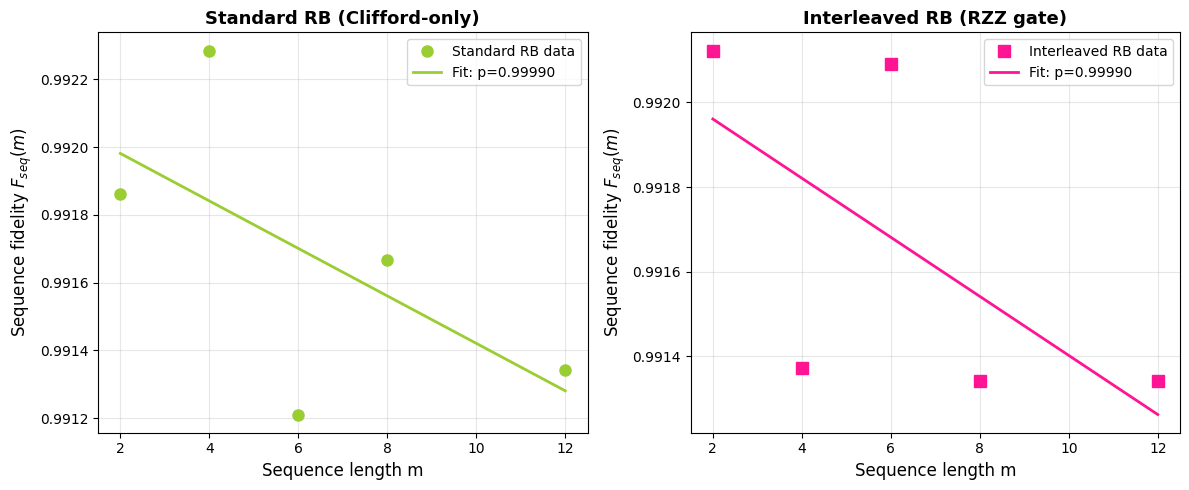

In [87]:
#Plot Standard RB and Interleaved RB comparison (RZZ)
plt.figure(figsize=(12, 5))

#Standard RB plot
plt.subplot(1, 2, 1)
plt.plot(m_vals, F_seq_rb, 'o', markersize=8, label='Standard RB data', color='yellowgreen')
plt.plot(m_vals, fit_func(m_vals, *params_rb), '-', linewidth=2, label=f'Fit: p={p_rb:.5f}', color='yellowgreen')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Standard RB (Clifford-only)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

#Interleaved RB plot (RZZ)
plt.subplot(1, 2, 2)
plt.plot(m_vals, F_seq_irb, 's', markersize=8, label='Interleaved RB data', color='deeppink')
plt.plot(m_vals, fit_func(m_vals, *params_irb), '-', linewidth=2, label=f'Fit: p={p_irb:.5f}', color='deeppink')
plt.xlabel('Sequence length m', fontsize=12)
plt.ylabel('Sequence fidelity $F_{seq}(m)$', fontsize=12)
plt.title('Interleaved RB (RZZ gate)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
# Show one of the actual sequences used in the RB/IRB runs (same seeds as above)
# Adjust m_view and k_view if you want a different sequence; interleaved=True shows RZ-gate IRB.
m_view = 4         # must be in sequence_lengths
k_view = 0          # 0-based index into the num_sequences draws
interleaved = True # False = Standard RB, True = Interleaved RB (RZ gate)

if m_view not in sequence_lengths:
    raise ValueError(f"m_view {m_view} not in sequence_lengths {sequence_lengths}")
if not (0 <= k_view < num_sequences):
    raise ValueError(f"k_view {k_view} must be between 0 and {num_sequences-1}")

seed_offset = 99999 if interleaved else 0
seed = seed_base + m_view * 1000 + k_view + seed_offset

seq = create_rb_sequence(
    clifford_circuits=cliffords_list,
    m=m_view,
    target_gate_circuit=(target_RZ if interleaved else None),
    seed=seed,
 )

seq_label = "Interleaved RB (RZ gate)" if interleaved else "Standard RB"
seq_gate_tuple = extract_gate_sequence(seq)

print(f"{seq_label} — actual sequence used during run")
print(f"m = {m_view}, sequence index k = {k_view}, seed = {seed}")
print(f"Gate tuple: {seq_gate_tuple}")
print(f"Circuit depth: {seq.depth()}")
print(f"Number of gates (incl. measure): {len(seq.data)}")

%matplotlib inline
fig = seq.draw('mpl')
plt.show()

NameError: name 'sequence_lengths' is not defined

In [89]:
#Debug Fit order 1
print("m_vals:", m_vals)
print("F_seq_irb:", F_seq_irb)
print("p0:", [0.5, 0.99, 0.01, 0.5])
print("bounds:", ([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0]))

m_vals: [ 2  4  6  8 12]
F_seq_irb: [0.9921224  0.9913737  0.99208984 0.99134115 0.99134115]
p0: [0.5, 0.99, 0.01, 0.5]
bounds: ([0.0, 0.9, -1.0, 0.0], [1.0, 1.0, 1.0, 1.0])
